In [10]:
# 지역 경계를 그리는 함수
import geopandas as gpd

shp_path = r"C:\Users\user00\Desktop\MCI_Diffusion\MCI_ADV2\scenarios\ctprvn.shp"
gdf = gpd.read_file(shp_path)


def overlay_national_boundary(ax, color='black', linewidth=0.8, linestyle='-', 
                               label_regions=False, fontsize=7):
    """전국 시도 경계를 지도 위에 오버레이합니다."""
    try:
        gdf_wgs84 = gdf.set_crs(epsg=5179, allow_override=True).to_crs(epsg=4326)
        gdf_wgs84 = gdf_wgs84[gdf_wgs84['CTP_ENG_NM'].str.lower() != 'jeju-do']
        gdf_wgs84.boundary.plot(ax=ax, color=color, linewidth=linewidth, linestyle=linestyle)
        
        if label_regions:
            for _, row in gdf_wgs84.iterrows():
                centroid = row.geometry.centroid
                name = row.get('CTP_KOR_NM', row.get('CTP_ENG_NM', ''))
                ax.text(centroid.x, centroid.y, name,
                        fontsize=fontsize, ha='center', va='center',
                        fontproperties=font_prop if 'font_prop' in dir() else None)
    except Exception as e:
        print(f"[WARN] national boundary overlay skipped: {e}")


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import re

In [12]:
# 사용 데이터 정의 
plt.style.use('seaborn-v0_8-whitegrid')
METADATA_PATH = r"C:\Users\user00\Desktop\MCI_Diffusion\MCI_ADV2\scenarios"

# {region}_exp_{date}_{time} 패턴 폴더에서 random_metadata.csv 수집
pattern = re.compile(r"^(.+?)_exp_(\d{8})_(\d{6})$")

records = []
for folder in os.listdir(METADATA_PATH):
    m = pattern.match(folder)
    if not m:
        continue
    region, date, time_ = m.group(1), m.group(2), m.group(3)
    csv_path = os.path.join(METADATA_PATH, folder, "random_metadata.csv")
    if not os.path.exists(csv_path):
        continue
    df = pd.read_csv(csv_path)
    df['region'] = region
    df['exp_date'] = date
    df['exp_time'] = time_
    records.append(df)

metadata_all = pd.concat(records, ignore_index=True)
print(f"총 {len(metadata_all)}개 시나리오, {metadata_all['region'].nunique()}개 지역")
print(metadata_all['region'].value_counts())


총 445850개 시나리오, 15개 지역
region
gangwon      93000
jeonnam      68000
gyeongbuk    60950
gyeonggi     56000
chungnam     45500
jeonbuk      45000
chungbuk     41000
daegu         8300
incheon       6000
ulsan         6000
busan         4300
seoul         3400
daejeon       3000
gwangju       2800
sejong        2600
Name: count, dtype: int64


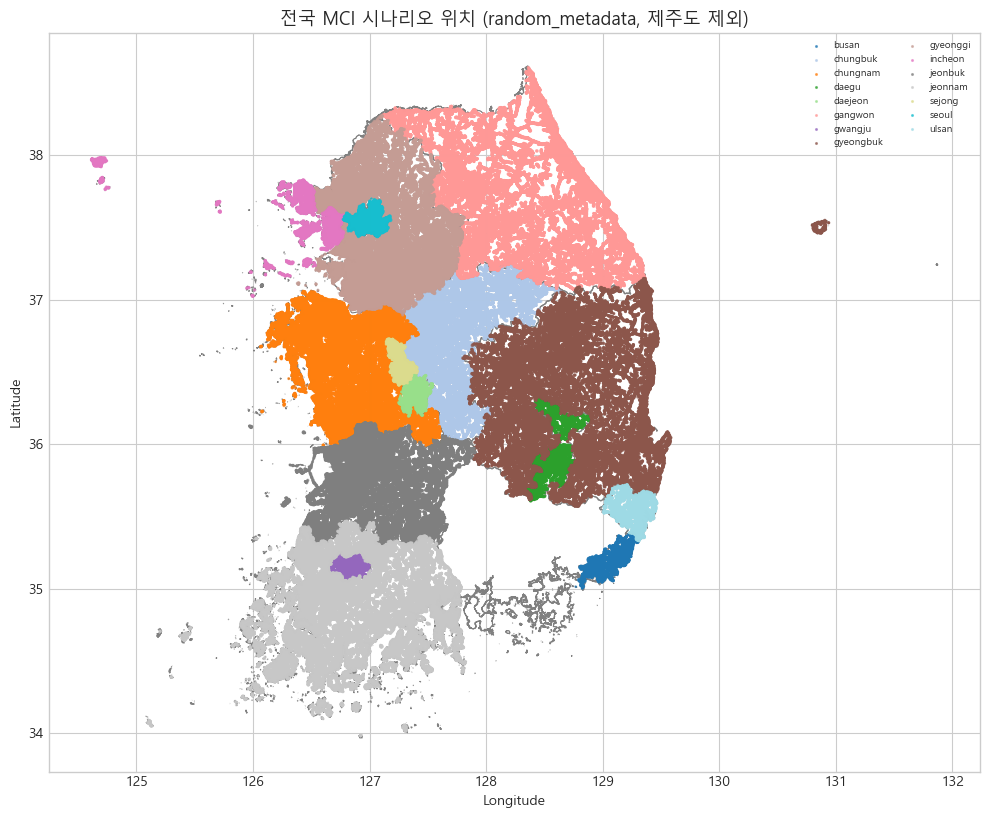

In [15]:
# 메타 데이터 전국 시각화 
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(10, 12))

# 전국 경계 오버레이 (제주 제외)
overlay_national_boundary(ax, color='gray', linewidth=0.8)

# 지역별 색상 구분 (제주 제외)
metadata_plot = metadata_all[metadata_all['region'] != 'Jeju-do']
regions = metadata_plot['region'].unique()
colors = cm.tab20(np.linspace(0, 1, len(regions)))
color_map = dict(zip(regions, colors))

for region, grp in metadata_plot.groupby('region'):
    ax.scatter(
        grp['snapped_longitude'], grp['snapped_latitude'],
        s=grp['N'] * 0.05,
        color=color_map[region],
        alpha=0.6,
        label=region,
        zorder=3
    )

ax.legend(loc='upper right', fontsize=7, ncol=2, framealpha=0.8)
ax.set_title("전국 MCI 시나리오 위치 (random_metadata, 제주도 제외)", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()
